<a href="https://colab.research.google.com/github/rahul-7718/MEACHINE-LEARNING/blob/main/2420080025_WEEK_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

COMPARING DIFFERENT ARCHITECTURES
Hidden neurons:  2 -> Accuracy: 100%
Hidden neurons:  4 -> Accuracy: 100%
Hidden neurons:  8 -> Accuracy: 100%


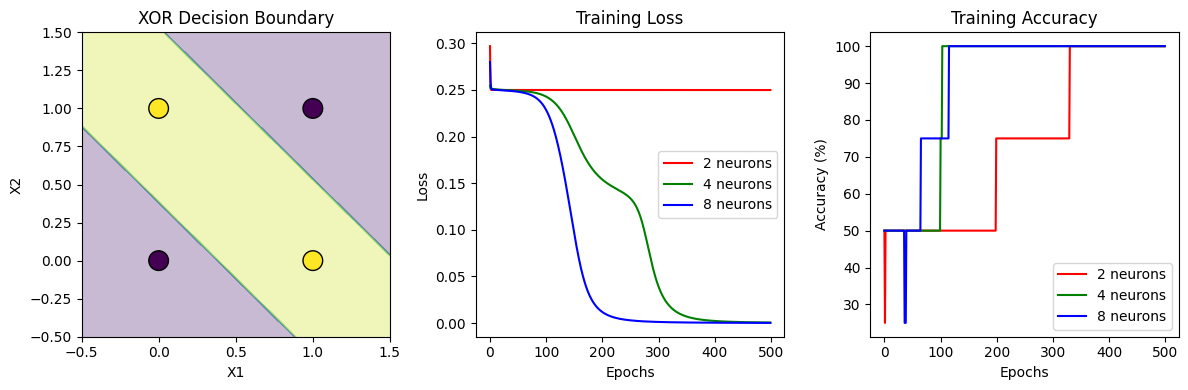


SUMMARY
✔ Perceptron: Works for AND/OR but fails for XOR (linear)
✔ 2-Layer NN: Successfully learns XOR (non-linear)
✔ More hidden neurons → Faster learning (generally)
✔ Implemented from scratch using NumPy


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# MODEL (Keras-like)
# =========================
class SimpleKeras:
    def __init__(self, hidden_neurons=4, lr=0.5):
        self.lr = lr

        self.W1 = np.random.randn(2, hidden_neurons) * 0.5
        self.b1 = np.zeros(hidden_neurons)

        self.W2 = np.random.randn(hidden_neurons, 1) * 0.5
        self.b2 = np.zeros(1)

        self.losses = []
        self.accuracies = []

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def fit(self, X, y, epochs=1000):
        y = y.reshape(-1, 1)

        for _ in range(epochs):
            # Forward
            hidden = self.sigmoid(np.dot(X, self.W1) + self.b1)
            output = self.sigmoid(np.dot(hidden, self.W2) + self.b2)

            # Loss
            loss = np.mean((y - output) ** 2)
            self.losses.append(loss)

            # Accuracy
            acc = np.mean((output > 0.5) == y) * 100
            self.accuracies.append(acc)

            # Backward
            d_output = output - y
            d_hidden = d_output.dot(self.W2.T) * hidden * (1 - hidden)

            # Update
            self.W2 -= self.lr * hidden.T.dot(d_output)
            self.b2 -= self.lr * np.sum(d_output, axis=0)

            self.W1 -= self.lr * X.T.dot(d_hidden)
            self.b1 -= self.lr * np.sum(d_hidden, axis=0)

    def predict(self, X):
        hidden = self.sigmoid(np.dot(X, self.W1) + self.b1)
        output = self.sigmoid(np.dot(hidden, self.W2) + self.b2)
        return (output > 0.5).astype(int).flatten()


# =========================
# DATASET
# =========================
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y_xor = np.array([0,1,1,0])

# =========================
# TEST DIFFERENT HIDDEN SIZES
# =========================
print("=" * 60)
print("COMPARING DIFFERENT ARCHITECTURES")
print("=" * 60)

for neurons in [2, 4, 8]:
    model = SimpleKeras(hidden_neurons=neurons)
    model.fit(X, y_xor, epochs=1000)

    pred = model.predict(X)
    accuracy = np.mean(pred == y_xor) * 100

    print(f"Hidden neurons: {neurons:2d} -> Accuracy: {accuracy:.0f}%")


# =========================
# VISUALIZATION
# =========================
plt.figure(figsize=(12, 4))

# =========================
# PLOT 1: DECISION BOUNDARY
# =========================
plt.subplot(1, 3, 1)

model_viz = SimpleKeras(hidden_neurons=4)
model_viz.fit(X, y_xor, epochs=1000)

# Grid
xx, yy = np.meshgrid(
    np.linspace(-0.5, 1.5, 100),
    np.linspace(-0.5, 1.5, 100)
)

grid = np.c_[xx.ravel(), yy.ravel()]
Z = model_viz.predict(grid).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y_xor, s=200, edgecolor='black')

plt.title("XOR Decision Boundary")
plt.xlabel("X1")
plt.ylabel("X2")


# =========================
# PLOT 2: LOSS CURVES
# =========================
plt.subplot(1, 3, 2)

for neurons, color in zip([2, 4, 8], ['red', 'green', 'blue']):
    m = SimpleKeras(neurons)
    m.fit(X, y_xor, epochs=500)
    plt.plot(m.losses, color=color, label=f"{neurons} neurons")

plt.title("Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()


# =========================
# PLOT 3: ACCURACY CURVES
# =========================
plt.subplot(1, 3, 3)

for neurons, color in zip([2, 4, 8], ['red', 'green', 'blue']):
    m = SimpleKeras(neurons)
    m.fit(X, y_xor, epochs=500)
    plt.plot(m.accuracies, color=color, label=f"{neurons} neurons")

plt.title("Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()

plt.tight_layout()
plt.show()


# =========================
# SUMMARY
# =========================
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)

print("✔ Perceptron: Works for AND/OR but fails for XOR (linear)")
print("✔ 2-Layer NN: Successfully learns XOR (non-linear)")
print("✔ More hidden neurons → Faster learning (generally)")
print("✔ Implemented from scratch using NumPy")
